# MAQT & Certified Radius $R$
## CICIoT2023 | Reuse Day-16 Checkpoint | Target (y) = "label_multiclass" | Data Reupload = 2

### To Implement: $ R = \frac{m}{2(1-p)\,L_\varphi\,C_f} $

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from pennylane import numpy as np

In [2]:
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.constants import (
    DEFAULT_BATCH_SIZE,
    DEFAULT_CF,
    DEFAULT_LAMBDA1,
    DEFAULT_LAMBDA2,
    DEFAULT_LR,
    DEFAULT_NOISE_RATE,
    ZERO_DAY,
)
from scripts.data import (
    capped_sample,
    load_split,
    plot_class_balance_pie,
)
from scripts.inference import qsnet_infer_batch
from scripts.logging import write_history_log
from scripts.prototypes import prototype_summary
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: CICIoT2023

In [4]:
NOTEBOOK_NAME = "17.certified-radius_ciciot2023"
DAY16_NOTEBOOK = "16.estimate-lipschitz_ciciot2023"
dataset = "CICIoT2023"
split_prefix = "q8"
target_col = "label_multiclass"
data_path = f"data/{dataset}/quantum"

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [6]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [7]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['Backdoor_Malware',
 'BenignTraffic',
 'BrowserHijacking',
 'CommandInjection',
 'DDoS-ACK_Fragmentation',
 'DDoS-HTTP_Flood',
 'DDoS-ICMP_Flood',
 'DDoS-ICMP_Fragmentation',
 'DDoS-PSHACK_Flood',
 'DDoS-RSTFINFlood',
 'DDoS-SYN_Flood',
 'DDoS-SlowLoris',
 'DDoS-SynonymousIP_Flood',
 'DDoS-TCP_Flood',
 'DDoS-UDP_Flood',
 'DDoS-UDP_Fragmentation',
 'DNS_Spoofing',
 'DictionaryBruteForce',
 'DoS-HTTP_Flood',
 'DoS-SYN_Flood',
 'DoS-TCP_Flood',
 'DoS-UDP_Flood',
 'MITM-ArpSpoofing',
 'Recon-HostDiscovery',
 'Recon-OSScan',
 'Recon-PingSweep',
 'Recon-PortScan',
 'SqlInjection',
 'Uploading_Attack',
 'VulnerabilityScan',
 'XSS']

In [8]:
# load full dataset
X_train_full, y_train_full = load_split(
    data_path, f"{split_prefix}_train", target_col, class_names
)
X_test, y_test = load_split(data_path, f"{split_prefix}_test", target_col, class_names)

In [9]:
# check shape
[X_train_full.shape, y_train_full.shape, X_test.shape, y_test.shape]

[(132166, 8), (132166,), (18883, 8), (18883,)]

## EDA (Before Subset)

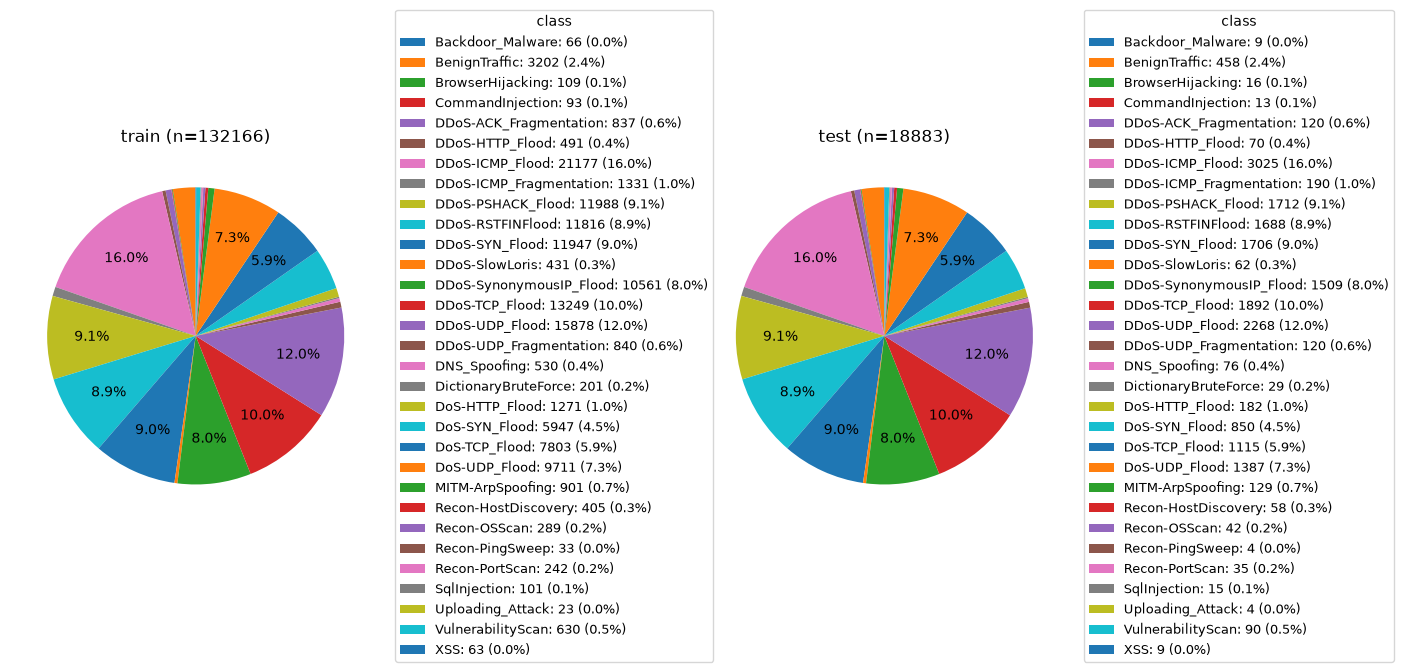

In [10]:
# pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_class_balance_pie(
    y_train_full,
    class_names,
    title=f"train (n={len(to_np_y(y_train_full))})",
    ax=axes[0],
)
plot_class_balance_pie(
    y_test,
    class_names,
    title=f"test (n={len(to_np_y(y_test))})",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

## Data Subset

In [11]:
SUBSET = True  # set to False for the full dataset
SEED = 42
PER_CLASS_CAP = 100  # matches Day-16 CICIoT protocol

In [12]:
if SUBSET is True:
    X_train, y_train = capped_sample(
        X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED
    )
else:
    X_train, y_train = X_train_full, y_train_full

# check shape
[X_train.shape, y_train.shape]

[(2878, 8), (2878,)]

## EDA (After Subset)

In [13]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

number of classes: 31
number of qubits: 8


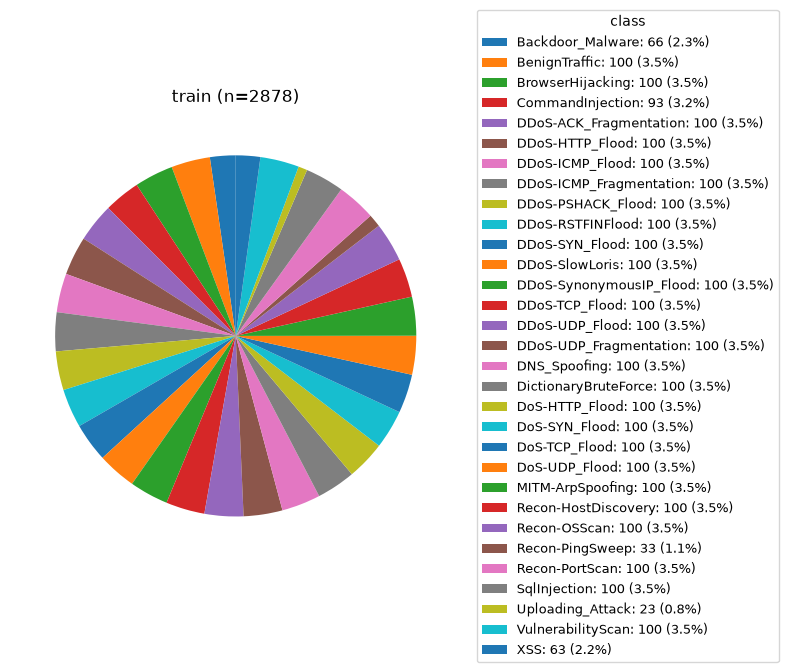

In [14]:
# pie chart
fig, ax = plt.subplots(figsize=(8, 8))

plot_class_balance_pie(
    y_train,
    class_names,
    title=f"train (n={len(to_np_y(y_train))})",
    ax=ax,
)

plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [15]:
num_layers = 2  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [16]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(
    num_qubits
)  # or dev = qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(
    dev, num_qubits, num_layers, noise_rate=noise_rate
)

## Load Day-16 Encoder + $L_\varphi$

This notebook reuses the Day-16 MAQT checkpoint ($\theta^\star$, prototypes) and the published $L_\varphi$ artifact.

Set `LOAD_CHECKPOINT = False` only to retrain as a fallback.

In [17]:
LOAD_CHECKPOINT = True
CHECKPOINT_CANDIDATES = [
    Path("artifacts") / dataset / f"{DAY16_NOTEBOOK}-checkpoint.pt",
]
LPHI_CANDIDATES = [
    Path("artifacts") / dataset / f"{DAY16_NOTEBOOK}-lphi.pt",
]

epochs = 10
batch_size = DEFAULT_BATCH_SIZE
lr = DEFAULT_LR
lambda1 = DEFAULT_LAMBDA1
lambda2 = DEFAULT_LAMBDA2
Cf = DEFAULT_CF

In [18]:
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
lphi_path = next((p for p in LPHI_CANDIDATES if p.exists()), None)
history = {}
head = None

# use model checkpoint if loading is enabled and a valid file exists
if LOAD_CHECKPOINT and ckpt_path is not None:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    theta_star = ckpt["theta"].to(device)
    if not isinstance(theta_star, torch.nn.Parameter):
        theta_star = torch.nn.Parameter(theta_star)
    prototypes = {int(k): v.to(device) for k, v in ckpt["prototypes"].items()}
    noise_rate = float(ckpt.get("noise_rate", noise_rate))
    num_layers = int(ckpt.get("num_layers", num_layers))

    # rebuild circuit if checkpoint meta differs
    forward_circuit = build_forward_circuit(
        dev, num_qubits, num_layers, noise_rate=noise_rate
    )
    print(f"loaded checkpoint: {ckpt_path}")
    print(f"theta shape: {tuple(theta_star.shape)} | prototypes: {len(prototypes)}")

# train from scratch if checkpoint loading is disabled or no checkpoint exists
else:
    if LOAD_CHECKPOINT:
        print("checkpoint not found; falling back to MAQT train")
    theta, head, prototypes, ema_protos, history = train_maqt(
        X_train,
        y_train,
        n_classes=num_classes,
        n_qubits=num_qubits,
        n_layers=num_layers,
        forward_circuit=forward_circuit,
        device=device,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size,
        lambda1_max=lambda1,
        lambda2_max=lambda2,
        use_weighted_sampler=True,
    )
    theta_star = theta
    print(
        f"trained encoder: theta shape={tuple(theta_star.shape)} | prototypes={len(prototypes)}"
    )

loaded checkpoint: artifacts/CICIoT2023/16.estimate-lipschitz_ciciot2023-checkpoint.pt
theta shape: (2, 8, 3) | prototypes: 31


In [19]:
# load Day-16 L_phi (required for R)
if lphi_path is not None:
    lphi_art = torch.load(lphi_path, map_location="cpu", weights_only=False)
    L_phi_estimated = float(lphi_art["L_phi_estimated"])
    L_phi_percentile = float(lphi_art.get("L_phi_percentile", 95.0))
    L_phi_analytic = float(lphi_art.get("L_phi_analytic", float("nan")))
    print(f"loaded L_phi from: {lphi_path}")
    print(f"L_phi (p{L_phi_percentile:g}) : {L_phi_estimated:.4f}")
    print(f"L_phi (analytic)              : {L_phi_analytic:.4f}")
else:
    raise FileNotFoundError(
        f"Day-16 L_phi artifact not found under artifacts/{dataset}/. "
        "Run 16.estimate-lipschitz_ciciot2023.ipynb first."
    )

loaded L_phi from: artifacts/CICIoT2023/16.estimate-lipschitz_ciciot2023-lphi.pt
L_phi (p95) : 0.6600
L_phi (analytic)              : 1.0000


## Algo 3: Certified Radius (Line 8) from Unified Inference with Disentangled Rejection

At test time, known-class inference yields a label plus certified radius
$$
R = \frac{m}{2(1-p)\,L_\varphi\,C_f},
$$
where $m$ is the fidelity margin (top-1 minus top-2 fidelity to class prototypes).

Here, every test sample is forced to get a class label by setting a permissive novelty threshold $q=1$. This turns off rejection so the certified-radius distribution is reported on correctly classified samples, not zero-day detection.

### Certified-Radius Distribution (Correctly Classified Test)

1. Run fidelity-based inference on known test.
2. Keep samples with $\hat y = y$.
3. Plot the empirical distribution of $R$.

In [20]:
q = 1.0  # turn off rejection # permissive, no CQ-ZDR
p = float(noise_rate)
L_phi = L_phi_analytic

print(f"dataset         : {dataset}")
print(f"noise rate (p)  : {p}")
print(f"L_phi (analytic): {L_phi:.4f}")
print(f"C_f             : {Cf}")
print(f"q               : {q}")
print(f"n_test          : {len(to_np_y(y_test))}")

dataset         : CICIoT2023
noise rate (p)  : 0.01
L_phi (analytic): 1.0000
C_f             : 1.0
q               : 1.0
n_test          : 18883


In [21]:
# Algorithm 3 line 8 on known test (batched)
y_pred, radii, novelty_scores, f_maps = qsnet_infer_batch(
    X_test,
    theta_star,
    prototypes,
    q,
    forward_circuit,
    p=p,
    L_phi=L_phi,
    Cf=Cf,
    zero_day=ZERO_DAY,
    device=device,
    batch_size=batch_size,
)

y_true = to_np_y(y_test).astype(int)
correct_mask = (y_pred == y_true) & (y_pred != ZERO_DAY)
radii_correct = radii[correct_mask]

n_test = len(y_true)
n_correct = int(correct_mask.sum())
acc = float(correct_mask.mean()) if n_test else float("nan")
mean_R = float(radii_correct.mean()) if n_correct else float("nan")
median_R = float(np.median(radii_correct)) if n_correct else float("nan")

print(f"test accuracy (prototype fidelity): {acc:.4f} ({n_correct}/{n_test})")
print(f"mean R (correct):   {mean_R:.6f}")
print(f"median R (correct): {median_R:.6f}")
if n_correct:
    print(f"R min/max (correct): {radii_correct.min():.6f} / {radii_correct.max():.6f}")

test accuracy (prototype fidelity): 0.4770 (9008/18883)
mean R (correct):   0.014033
median R (correct): 0.007401
R min/max (correct): 0.000003 / 0.225294


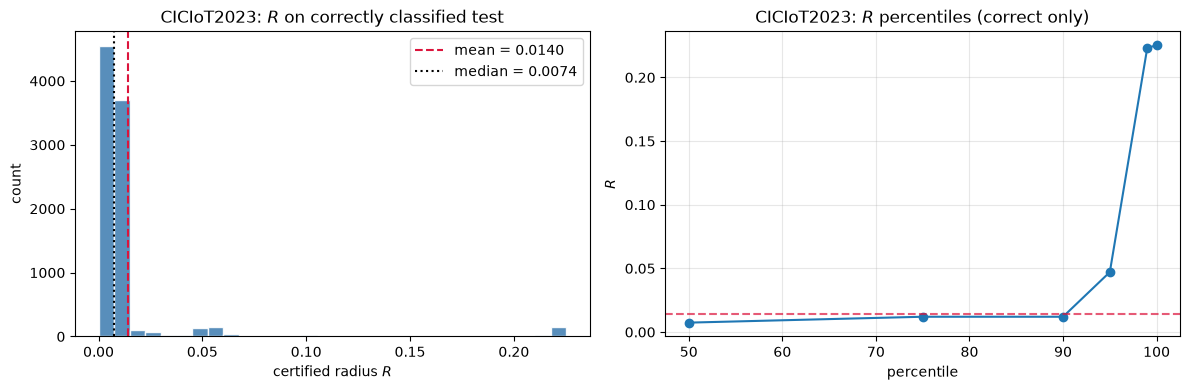

In [22]:
# plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(radii_correct, bins=30, color="steelblue", edgecolor="white", alpha=0.9)
if n_correct:
    axes[0].axvline(
        mean_R, color="crimson", linestyle="--", label=f"mean = {mean_R:.4f}"
    )
    axes[0].axvline(
        median_R, color="black", linestyle=":", label=f"median = {median_R:.4f}"
    )
axes[0].set_xlabel(r"certified radius $R$")
axes[0].set_ylabel("count")
axes[0].set_title(rf"{dataset}: $R$ on correctly classified test")
axes[0].legend()

pcts = [50, 75, 90, 95, 99, 100]
if n_correct:
    qvals = np.percentile(radii_correct, pcts)
    axes[1].plot(pcts, qvals, marker="o")
    axes[1].axhline(mean_R, color="crimson", linestyle="--", alpha=0.7)
axes[1].set_xlabel("percentile")
axes[1].set_ylabel(r"$R$")
axes[1].set_title(rf"{dataset}: $R$ percentiles (correct only)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
radius_df = pd.DataFrame(
    {
        "stat": [
            "n_test",
            "n_correct",
            "accuracy",
            "mean_R",
            "median_R",
            "p50",
            "p75",
            "p90",
            "p95",
            "p99",
            "max_R",
            "min_R",
            "L_phi_estimated",
            "L_phi_analytic",
            "p",
            "C_f",
        ],
        "value": [
            n_test,
            n_correct,
            acc,
            mean_R,
            median_R,
            float(np.percentile(radii_correct, 50)) if n_correct else float("nan"),
            float(np.percentile(radii_correct, 75)) if n_correct else float("nan"),
            float(np.percentile(radii_correct, 90)) if n_correct else float("nan"),
            float(np.percentile(radii_correct, 95)) if n_correct else float("nan"),
            float(np.percentile(radii_correct, 99)) if n_correct else float("nan"),
            float(radii_correct.max()) if n_correct else float("nan"),
            float(radii_correct.min()) if n_correct else float("nan"),
            L_phi_estimated,
            L_phi_analytic,
            p,
            Cf,
        ],
    }
)
radius_df

,stat,value
0,n_test,18883.000000
1,n_correct,9008.000000
2,accuracy,0.477043
3,mean_R,0.014033
4,median_R,0.007401
5,p50,0.007401
6,p75,0.012019
7,p90,0.012019
8,p95,0.047096
9,p99,0.223148


## Prototypes


In [24]:
proto_df = pd.DataFrame(prototype_summary(prototypes, class_names))
proto_df

,class,dim,trace
0,Backdoor_Malware,256,1.000000
1,BenignTraffic,256,1.000000
2,BrowserHijacking,256,1.000000
3,CommandInjection,256,1.000000
4,DDoS-ACK_Fragmentation,256,1.000000
5,DDoS-HTTP_Flood,256,1.000000
6,DDoS-ICMP_Flood,256,1.000000
7,DDoS-ICMP_Fragmentation,256,1.000000
8,DDoS-PSHACK_Flood,256,1.000000
9,DDoS-RSTFINFlood,256,1.000000


## Logging


In [25]:
# save certified-radius artifact
out_dir = Path("artifacts") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    "dataset": dataset,
    "notebook": NOTEBOOK_NAME,
    "L_phi_estimated": float(L_phi_estimated),
    "L_phi_analytic": float(L_phi_analytic),
    "used L_phi": float(L_phi),
    "p": float(p),
    "C_f": float(Cf),
    "q": float(q),
    "n_test": int(n_test),
    "n_correct": int(n_correct),
    "accuracy": float(acc),
    "mean_R": float(mean_R) if n_correct else None,
    "median_R": float(median_R) if n_correct else None,
    "radii_correct": radii_correct.tolist(),
    "checkpoint": str(ckpt_path) if ckpt_path is not None else None,
    "lphi_path": str(lphi_path) if lphi_path is not None else None,
}

radius_path = out_dir / f"{NOTEBOOK_NAME}-radii.pt"
torch.save(artifact, radius_path)
print("published radii:", radius_path.resolve())

published radii: /home/lawun330/Desktop/quantum-sentinel/artifacts/CICIoT2023/17.certified-radius_ciciot2023-radii.pt


In [26]:
# write log (final)
log_path = write_history_log(
    history if history else {"mean_R": [float(mean_R) if n_correct else None]},
    NOTEBOOK_NAME,
    extra={
        ## data
        "data_path": data_path,
        "dataset": dataset,
        "split_prefix": split_prefix,
        "target_col": target_col,
        "n_train": len(X_train),
        "n_test": int(n_test),
        "per_class_cap": PER_CLASS_CAP if SUBSET else None,
        "class_names": list(class_names),
        ## quantum model
        "noise_rate": float(p),
        "num_layers": int(num_layers),
        "num_qubits": int(num_qubits),
        "num_classes": int(num_classes),
        ## certified radius
        "L_phi_estimated": float(L_phi_estimated),
        "L_phi_analytic": float(L_phi_analytic),
        "used L_phi": float(L_phi),
        "C_f": float(Cf),
        "q": float(q),
        "n_correct": int(n_correct),
        "accuracy": float(acc),
        "mean_R": float(mean_R) if n_correct else None,
        "median_R": float(median_R) if n_correct else None,
        "checkpoint": str(ckpt_path) if ckpt_path is not None else None,
        "lphi_path": str(lphi_path) if lphi_path is not None else None,
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/quantum-sentinel/logs/17.certified-radius_ciciot2023.log
